In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nAttrition Count:\n", df['Attrition'].value_counts())

Shape: (1470, 35)

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Year

In [3]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Cleaned! New shape:", df.shape)
print("Attrition values:", df['Attrition'].unique())

Cleaned! New shape: (1470, 31)
Attrition values: [1 0]


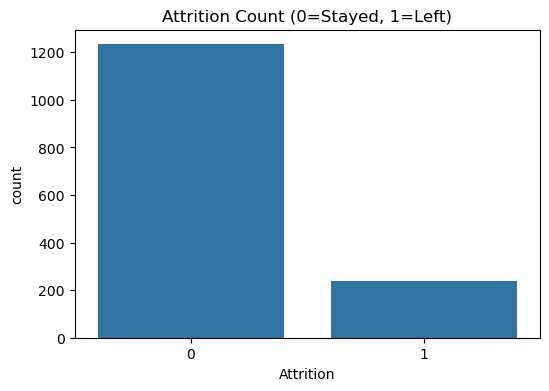

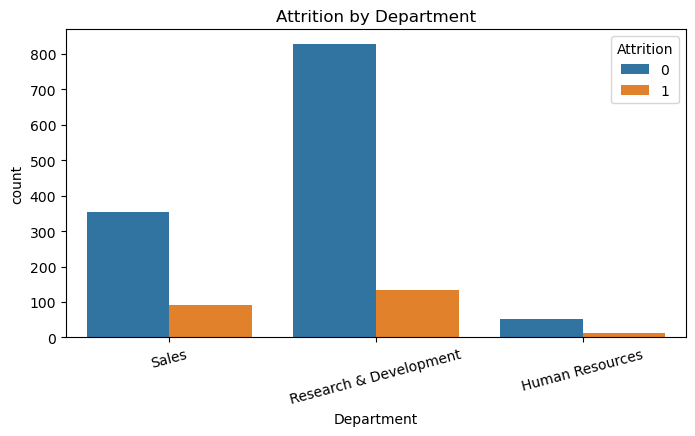

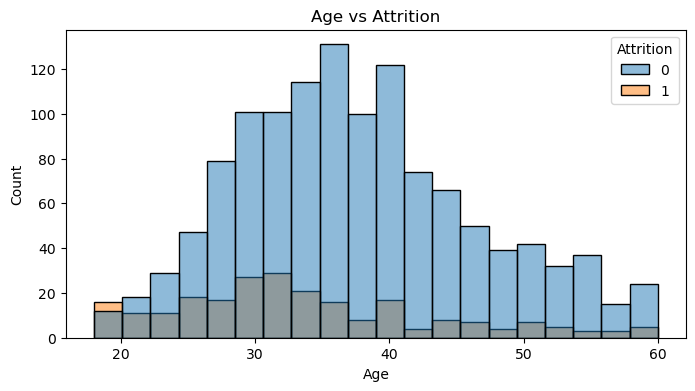

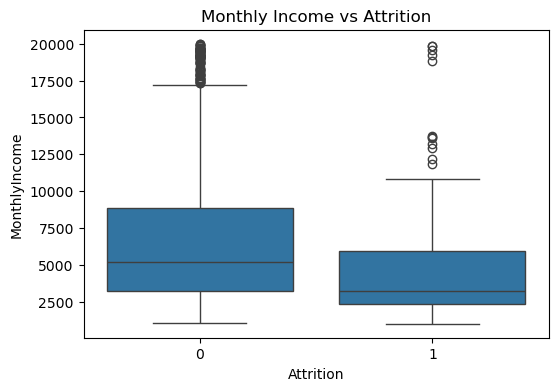

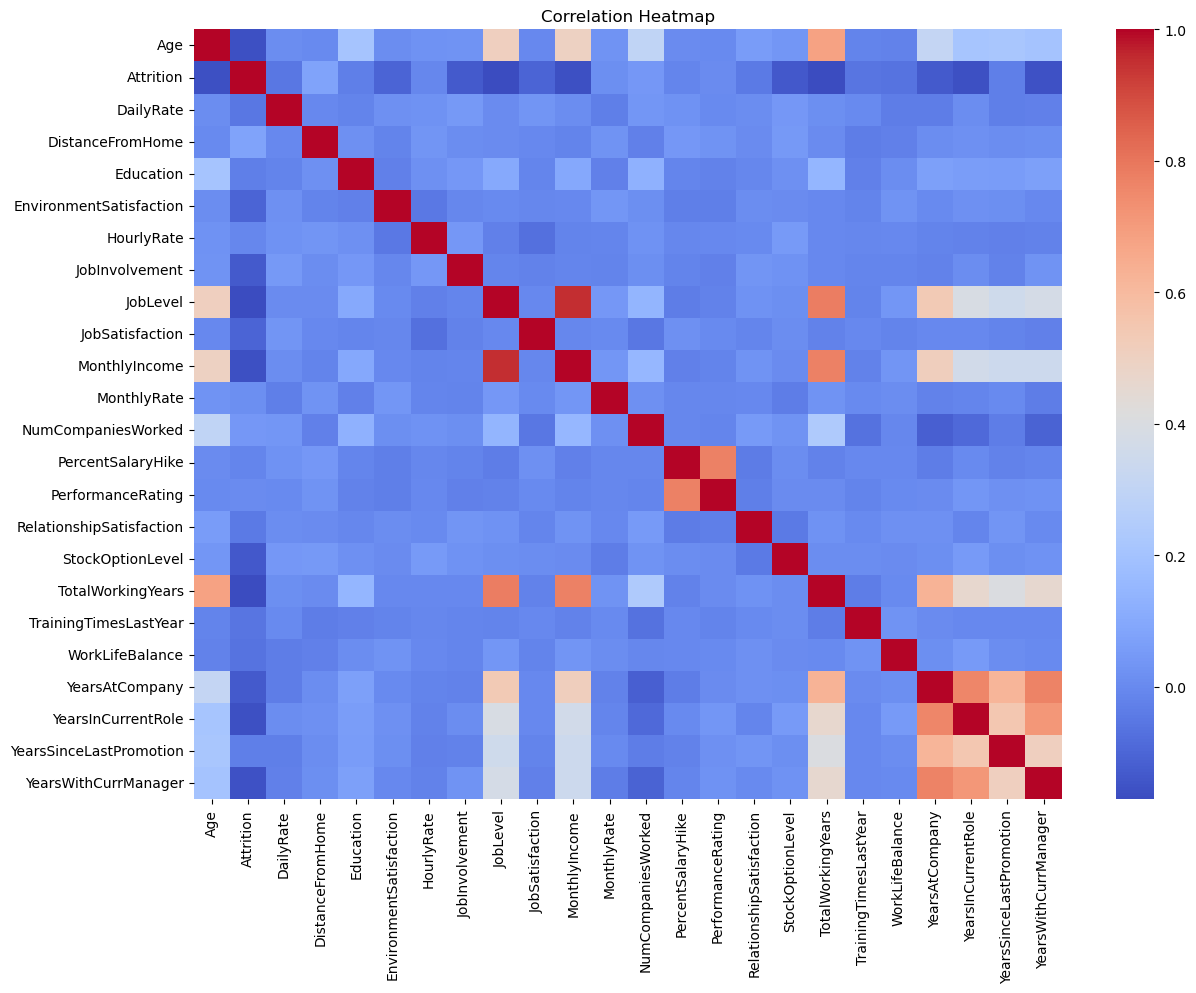

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Count (0=Stayed, 1=Left)')
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20)
plt.title('Age vs Attrition')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Done!")

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

X shape: (1470, 30)
y shape: (1470,)
Done!


Training size: (1176, 30)
Testing size: (294, 30)

Logistic Regression Accuracy: 89.46 %
Decision Tree Accuracy: 82.65 %


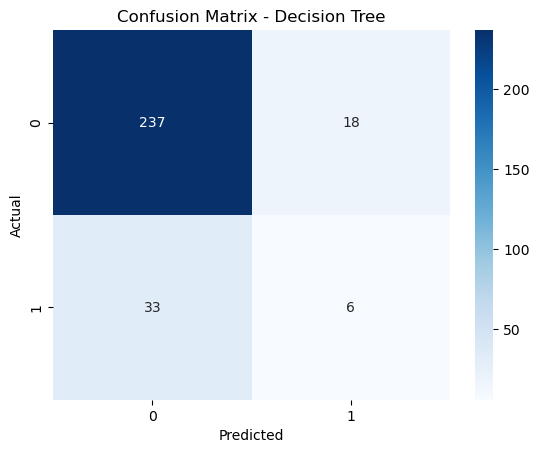


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       255
           1       0.25      0.15      0.19        39

    accuracy                           0.83       294
   macro avg       0.56      0.54      0.55       294
weighted avg       0.79      0.83      0.81       294



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Training size: (1176, 30)
Testing size: (294, 30)

Logistic Regression Accuracy: 89.46 %
Decision Tree Accuracy: 82.65 %


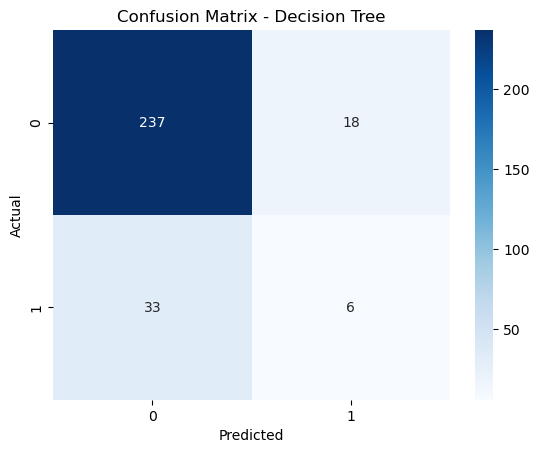


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       255
           1       0.25      0.15      0.19        39

    accuracy                           0.83       294
   macro avg       0.56      0.54      0.55       294
weighted avg       0.79      0.83      0.81       294



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr)*100, 2), "%")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

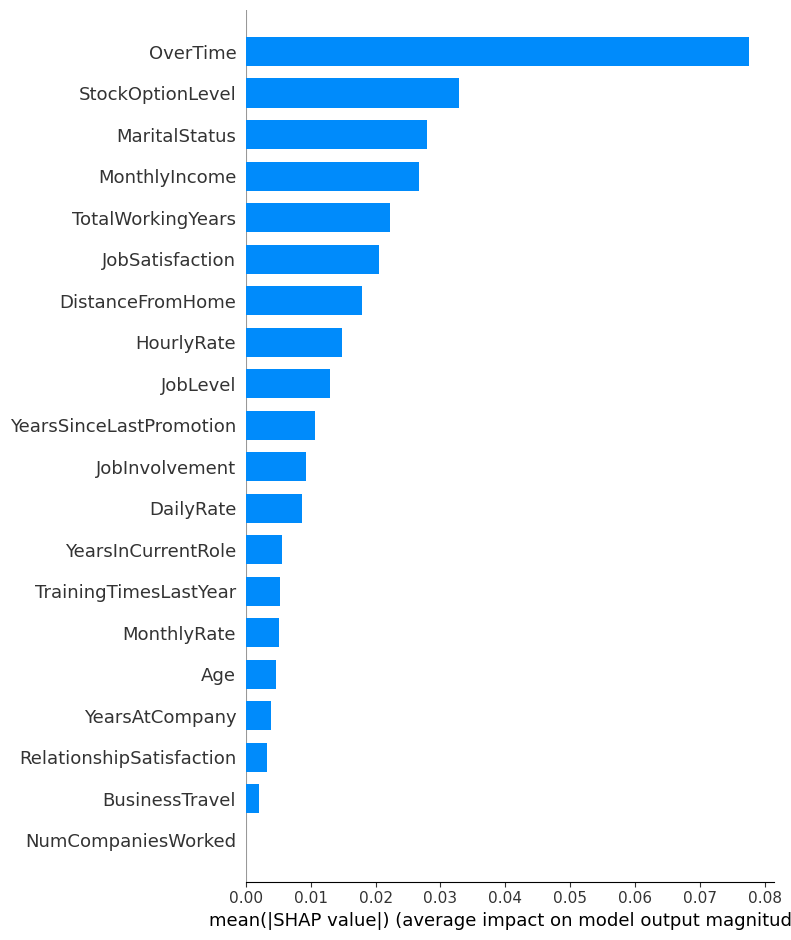

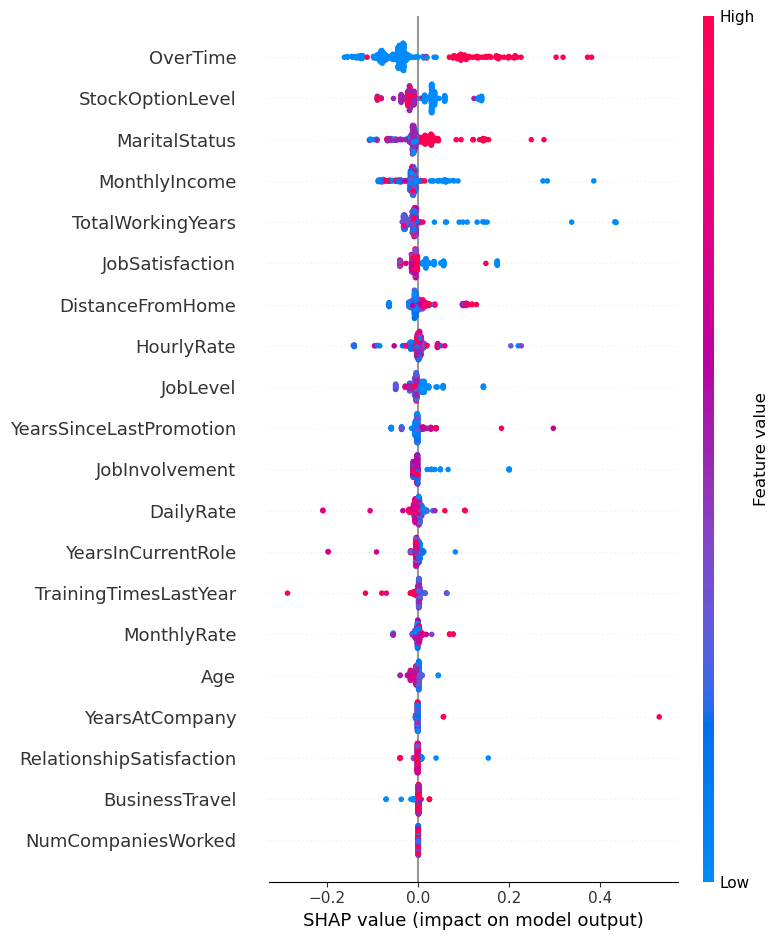

In [8]:
import shap

explainer = shap.TreeExplainer(dt)
shap_values = explainer.shap_values(X_test)

# Convert X_test back to dataframe with column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Bar plot - which features matter most
shap.summary_plot(shap_values[:,:,1], X_test_df, plot_type="bar")

# Dot plot - detailed view
shap.summary_plot(shap_values[:,:,1], X_test_df)

In [9]:
df.to_csv('hr_cleaned.csv', index=False)
print("File saved!")

import os
print("Saved at:", os.getcwd())

File saved!
Saved at: C:\Users\HOME\Downloads\HR_Attrition


In [10]:
import pickle

with open('hr_attrition_model.pkl', 'wb') as f:
    pickle.dump(dt, f)

print("Model saved!")

Model saved!
